---
## ***LOADING THE DATASET***
---

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn import preprocessing, metrics

# !pip install scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc


from sklearn.datasets import make_classification


In [ ]:
dementia_data2 = pd.read_csv('/content/dementia_patients_health_data.csv')
print(dementia_data2.head())
print(dementia_data2.columns)

   Diabetic  AlcoholLevel  HeartRate  BloodOxygenLevel  BodyTemperature  \
0         1      0.084974         98         96.230743        36.224852   
1         0      0.016973         78         93.032122        36.183874   
2         0      0.009000         89         93.566504        37.326321   
3         0      0.086437         60         93.906510        37.030620   
4         1      0.150747         67         97.508994        36.062121   

      Weight  MRI_Delay Prescription  Dosage in mg  Age  ...  Smoking_Status  \
0  57.563978  36.421028          NaN           NaN   60  ...  Current Smoker   
1  56.832335  31.157633  Galantamine          12.0   61  ...   Former Smoker   
2  59.759066  37.640435          NaN           NaN   69  ...   Former Smoker   
3  58.266471  50.673992    Donepezil          23.0   78  ...    Never Smoked   
4  67.705027  27.810601    Memantine          20.0   77  ...    Never Smoked   

    APOE_ε4  Physical_Activity Depression_Status Cognitive_Test_Scor

In [ ]:
missing_values = dementia_data2.isnull().sum()
print(missing_values)

Diabetic                       0
AlcoholLevel                   0
HeartRate                      0
BloodOxygenLevel               0
BodyTemperature                0
Weight                         0
MRI_Delay                      0
Prescription                 515
Dosage in mg                 515
Age                            0
Education_Level                0
Dominant_Hand                  0
Gender                         0
Family_History                 0
Smoking_Status                 0
APOE_ε4                        0
Physical_Activity              0
Depression_Status              0
Cognitive_Test_Scores          0
Medication_History             0
Nutrition_Diet                 0
Sleep_Quality                  0
Chronic_Health_Conditions    179
Dementia                       0
dtype: int64


---
## ***CLEANING THE DATA***
---

In [ ]:
# I will turn categorical data into numerical data by using label encoding rather than one - hot encoding because some of my categorical data has a natural ordinal relationship and because one- hot encoding wouldn't work for the prescription category
cat_data = dementia_data2
label_encoder=preprocessing.LabelEncoder()
colToEncode = ["Education_Level","Dominant_Hand", "Gender", "Family_History", "Smoking_Status", "APOE_ε4", "Medication_History", "Nutrition_Diet", "Sleep_Quality", "Chronic_Health_Conditions", "Physical_Activity", "Depression_Status", "Prescription", "Dosage in mg",'Cognitive_Test_Scores']
for i in colToEncode:
    cat_data[i] = label_encoder.fit_transform(dementia_data2[i])



In [ ]:
missing_values = dementia_data2.isnull().sum()
print(missing_values)

Diabetic                     0
AlcoholLevel                 0
HeartRate                    0
BloodOxygenLevel             0
BodyTemperature              0
Weight                       0
MRI_Delay                    0
Prescription                 0
Dosage in mg                 0
Age                          0
Education_Level              0
Dominant_Hand                0
Gender                       0
Family_History               0
Smoking_Status               0
APOE_ε4                      0
Physical_Activity            0
Depression_Status            0
Cognitive_Test_Scores        0
Medication_History           0
Nutrition_Diet               0
Sleep_Quality                0
Chronic_Health_Conditions    0
Dementia                     0
dtype: int64


In [ ]:
dementia_data2.head()      #to confirm that the categorical data are now numerical and there are no missing values

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Dosage in mg,Age,...,Smoking_Status,APOE_ε4,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,4,10,60,...,0,0,2,0,10,0,1,1,0,0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,1,7,61,...,1,1,1,0,1,1,1,1,1,1
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,4,10,69,...,1,0,1,0,8,0,2,1,1,0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,0,9,78,...,2,0,0,1,5,1,0,1,2,1
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,2,8,77,...,2,1,0,0,0,1,1,0,0,1


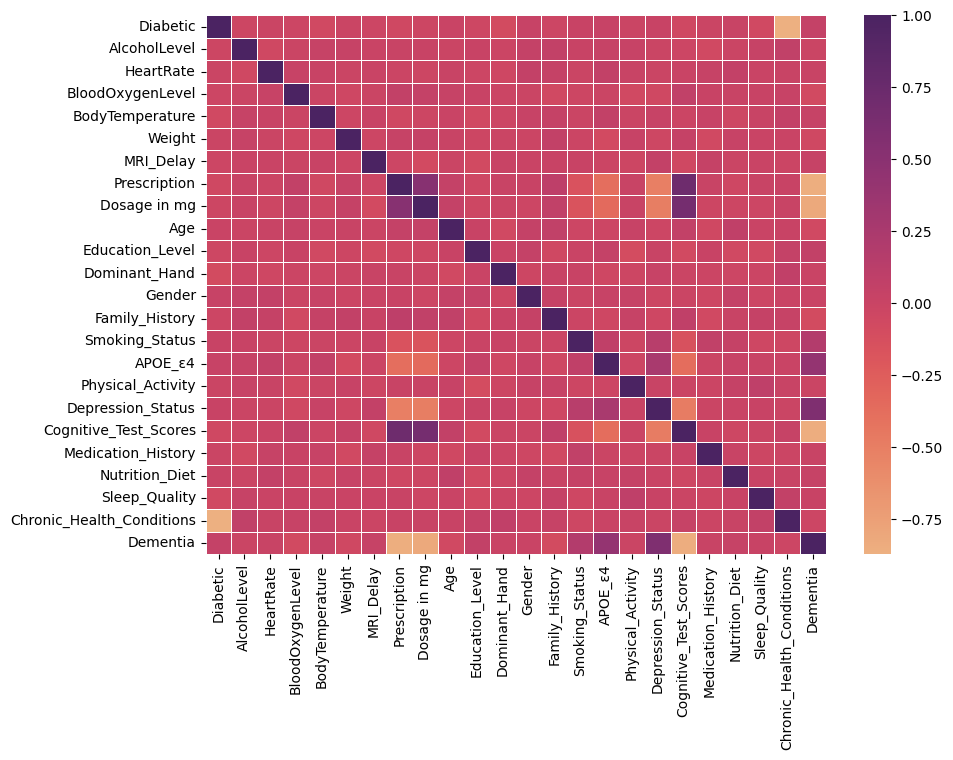

In [ ]:
#Visualizing the data after the category values turned into numerical values
plt.figure(figsize=(10, 7))
sns.heatmap(dementia_data2.corr(), cmap='flare', linewidths = .5)

plt.show()

In [ ]:
# I will remove the three features of the dataset that may be outliers for dementia becausethey may cause overfitting, I will explain more in the conclusion.
dementia_data2.drop(["Prescription", "Dosage in mg",'Cognitive_Test_Scores'], axis=1, inplace=True)
print(dementia_data2.columns)



Index(['Diabetic', 'AlcoholLevel', 'HeartRate', 'BloodOxygenLevel',
       'BodyTemperature', 'Weight', 'MRI_Delay', 'Age', 'Education_Level',
       'Dominant_Hand', 'Gender', 'Family_History', 'Smoking_Status',
       'APOE_ε4', 'Physical_Activity', 'Depression_Status',
       'Medication_History', 'Nutrition_Diet', 'Sleep_Quality',
       'Chronic_Health_Conditions', 'Dementia'],
      dtype='object')


---
# ***Training the Model***

---





###### For this part of the code, my independent variables is X. Y is my dependent or my target variable (Dementia)

###### test_size=0.3: 30% of the data will be used for testing, and 70% will be used for training.

###### random_state=101: Creates reproducibility with the data. Allows for the data to be split the same way each time the code is ran.

###### X_train and y_train: Will train the machine learning model.
###### X_test and y_test: Will evaluate the performance of the trained model.

#### ***Train-Test-Split***

In [ ]:
# Preparing the Data for Training

X = dementia_data2.drop('Dementia', axis = 1)
y = dementia_data2['Dementia']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state = 201) #test size divides between the train and test       #### IMPORTANT - random_state gives you randomized results every turn

---

## **DECISION TREE**
I did the model on accident, but I left it in this project because it helped me understand how random forest classifier works

In [ ]:
#####TRAINING THE CHOSEN MODEL (model = decision tree )

from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()

In [ ]:
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
print(X_train.head())
print(y_train.head())

     Diabetic  AlcoholLevel  HeartRate  BloodOxygenLevel  BodyTemperature  \
970         1      0.078675         93         91.500005        36.533927   
613         0      0.132238         88         99.994866        36.345663   
808         0      0.135690         67         98.291852        36.218791   
861         1      0.163414         92         91.250984        36.452809   
453         1      0.004344         80         99.353292        37.303451   

        Weight  MRI_Delay  Age  Education_Level  Dominant_Hand  Gender  \
970  83.275022  28.421330   86                3              0       0   
613  85.735958  51.078819   69                1              0       0   
808  92.539423   5.441067   82                1              0       1   
861  69.834054  28.055033   79                3              1       0   
453  89.499581  26.836907   82                0              0       1   

     Family_History  Smoking_Status  APOE_ε4  Physical_Activity  \
970               1      

In [ ]:
# TESTING DATA PREDCTION
prediction = dtree.predict(X_test)

In [ ]:
# CLASSIFICATION REPORT
print(" "*10 + 'CLASSIFICATION REPORT for DECISSION TREE\n' + '-'*60)

print(classification_report(y_test, prediction))   # prints an classification report on the testing data vs the prediction

# f1 evaluates if model is good by doing precision
# class 0 is a good job, class 1 youre not soing well ()too much true positives not enough false negatives(?)

          CLASSIFICATION REPORT for DECISSION TREE
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.69      0.71      0.70       156
           1       0.68      0.65      0.66       144

    accuracy                           0.68       300
   macro avg       0.68      0.68      0.68       300
weighted avg       0.68      0.68      0.68       300



In [ ]:
#CONFUSION MATRIX
print(confusion_matrix(y_test, prediction))

[[111  45]
 [ 50  94]]


In [ ]:
#DECISION TREE ACCURACY SCORE

from sklearn.metrics import accuracy_score

y_pred = dtree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Decission Tree Performance Accuracy:", accuracy)

Decission Tree Performance Accuracy: 0.6833333333333333


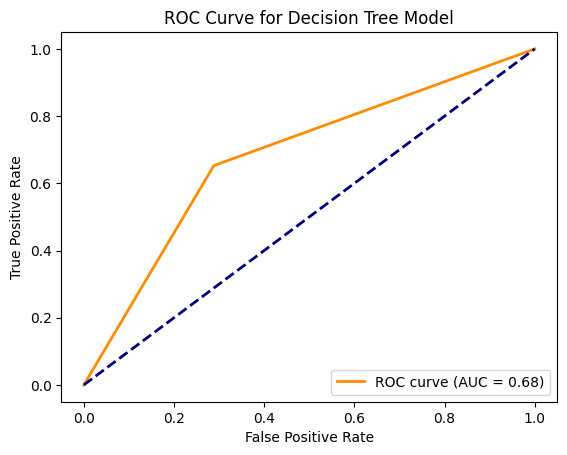

In [ ]:
#ROC CURVE AND AUC

#Prediction on the test data
y_pred_proba = dtree.predict_proba(X_test)[:, 1]  #Predict probabilities for the positives
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba) #False positive rate (FPR) true positive rate (TPR)

#Calculate AUC
roc_auc = auc(fpr, tpr)

#Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Decision Tree Model')
plt.legend(loc='lower right')
plt.show()

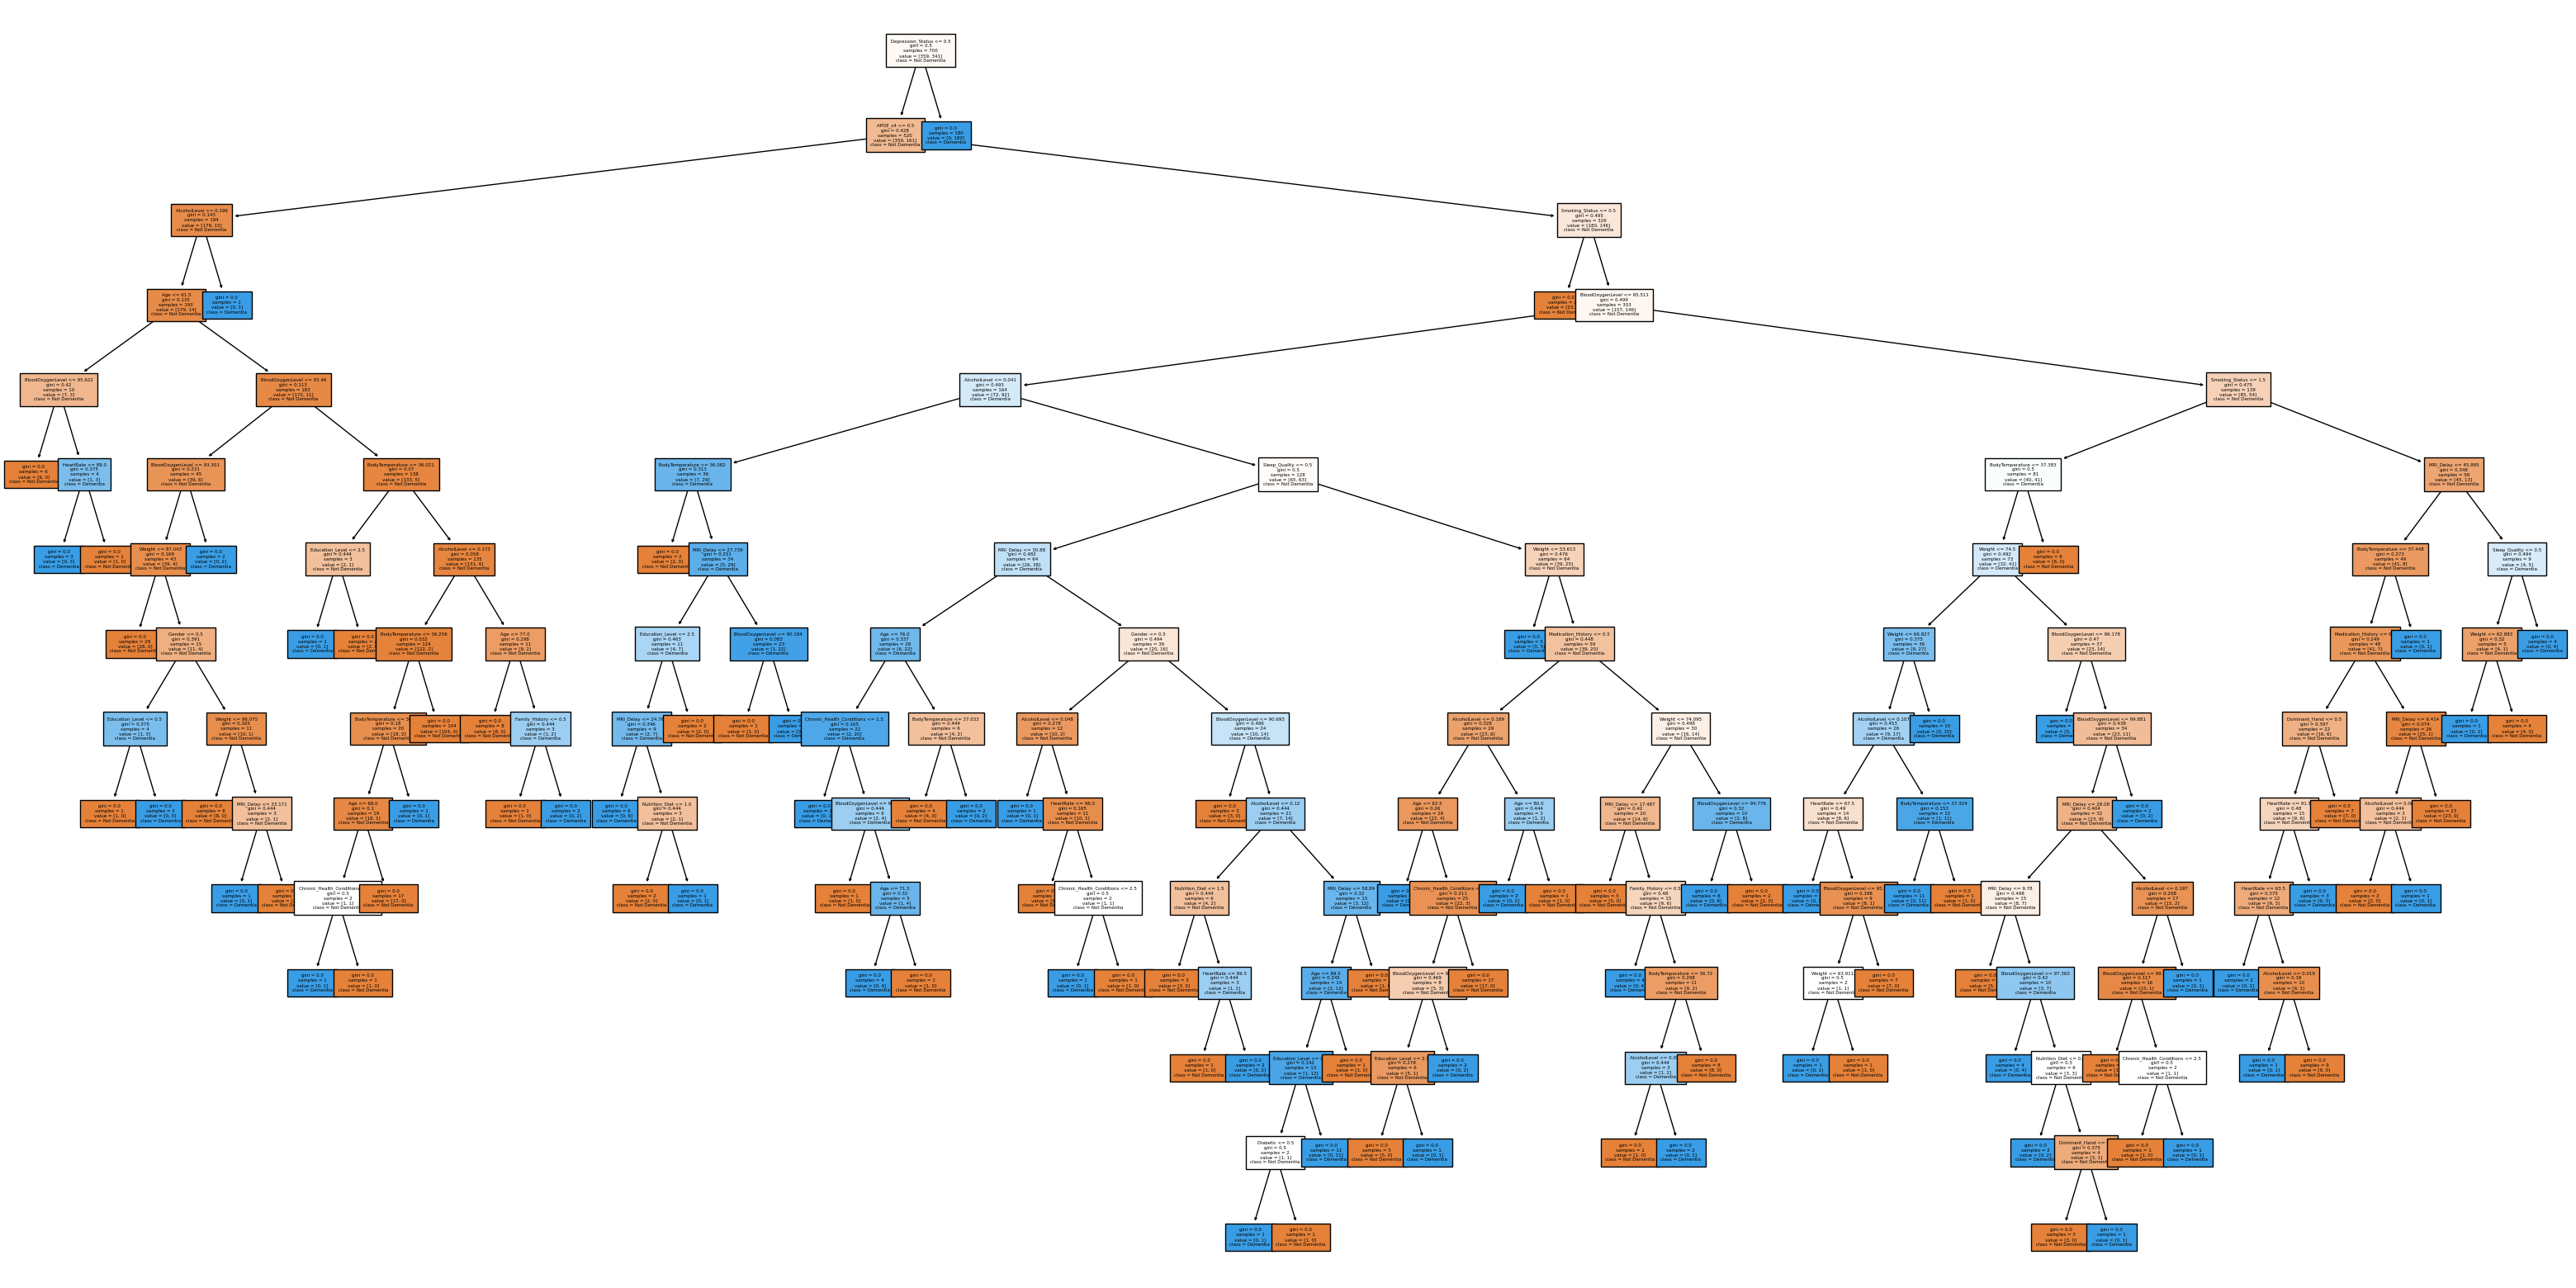

In [ ]:
#Decision Tree Plot
plt.figure(figsize=(40,20))  # Adjust the figsize as needed
plot_tree(dtree, feature_names=X.columns, class_names=['Not Dementia', 'Dementia'], filled=True, fontsize=4)
plt.show()

#19 descisions

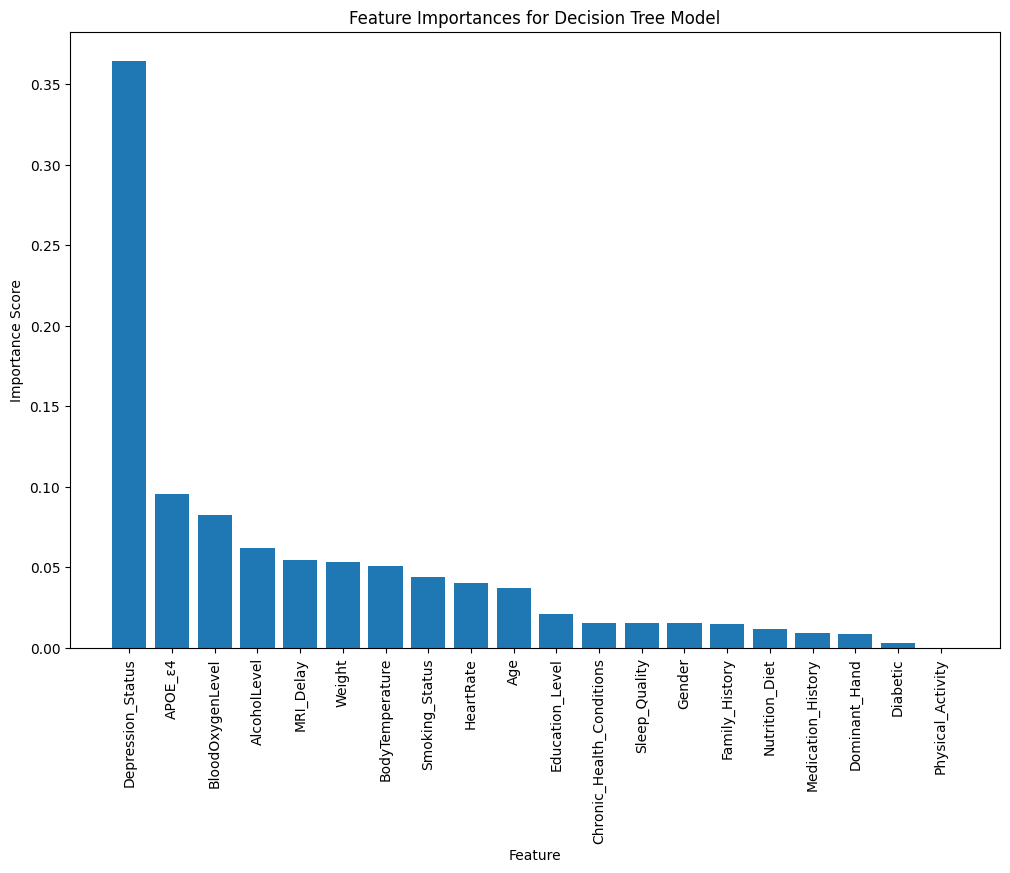

In [ ]:
#Feature of Importance Graph
importances = dtree.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 8))
plt.title("Feature Importances for Decision Tree Model")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.show()

---

### **RANDOM FOREST CLASSIFIER**

In [ ]:
#####TRAINING THE CHOSEN MODEL (model = random forest classifier)
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=200, random_state=101)

rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=101)

In [ ]:
# TESTING DATA PREDCTION
prediction_rfc = rfc.predict(X_test)

In [ ]:
# CLASSIFICATION REPORT
print(" "*4+'CLASSIFICATION REPORT for RANDOM FOREST CLASSIFIER\n' + '-'*60)
print(classification_report(y_test, prediction_rfc))


    CLASSIFICATION REPORT for RANDOM FOREST CLASSIFIER
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.73      0.89      0.80       156
           1       0.85      0.65      0.73       144

    accuracy                           0.77       300
   macro avg       0.79      0.77      0.77       300
weighted avg       0.79      0.77      0.77       300



In [ ]:
# CONFUSION MATRIX
cfm_rfc = confusion_matrix(y_test, prediction_rfc)
print(cfm_rfc)

[[139  17]
 [ 51  93]]


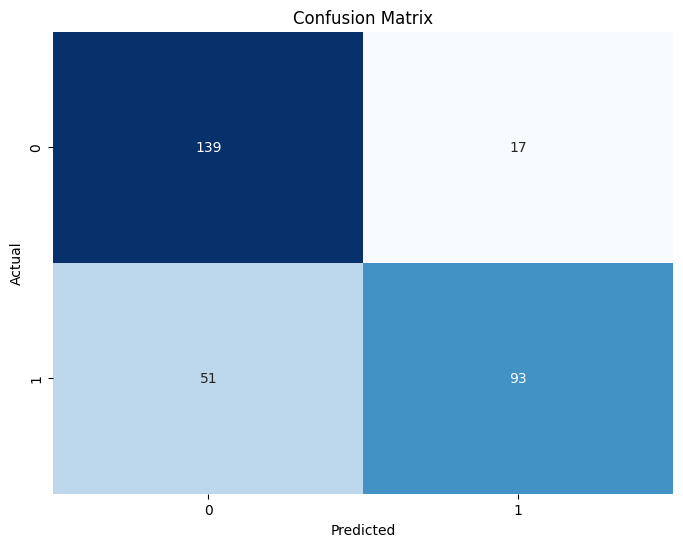

In [ ]:
# Plot confusion matrix as heatmap
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cfm_rfc, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# RANDOM DECISION CLASSIFIER ACCURACY SCORE
y_pred = rfc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.7733333333333333


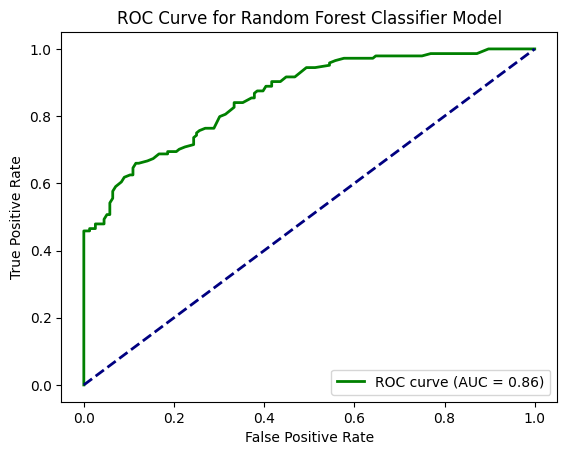

In [ ]:
#Predictions on the test data
y_pred_proba = rfc.predict_proba(X_test)[:, 1]  #Predict probabilities for the positives
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)   #False positive rate (FPR), true positive rate (TPR)

# Calculating AUC
roc_auc = auc(fpr, tpr)

# Plotting ROC curve
plt.figure()
plt.plot(fpr, tpr, color='green', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for Random Forest Classifier Model')
plt.legend(loc='lower right')
plt.show()

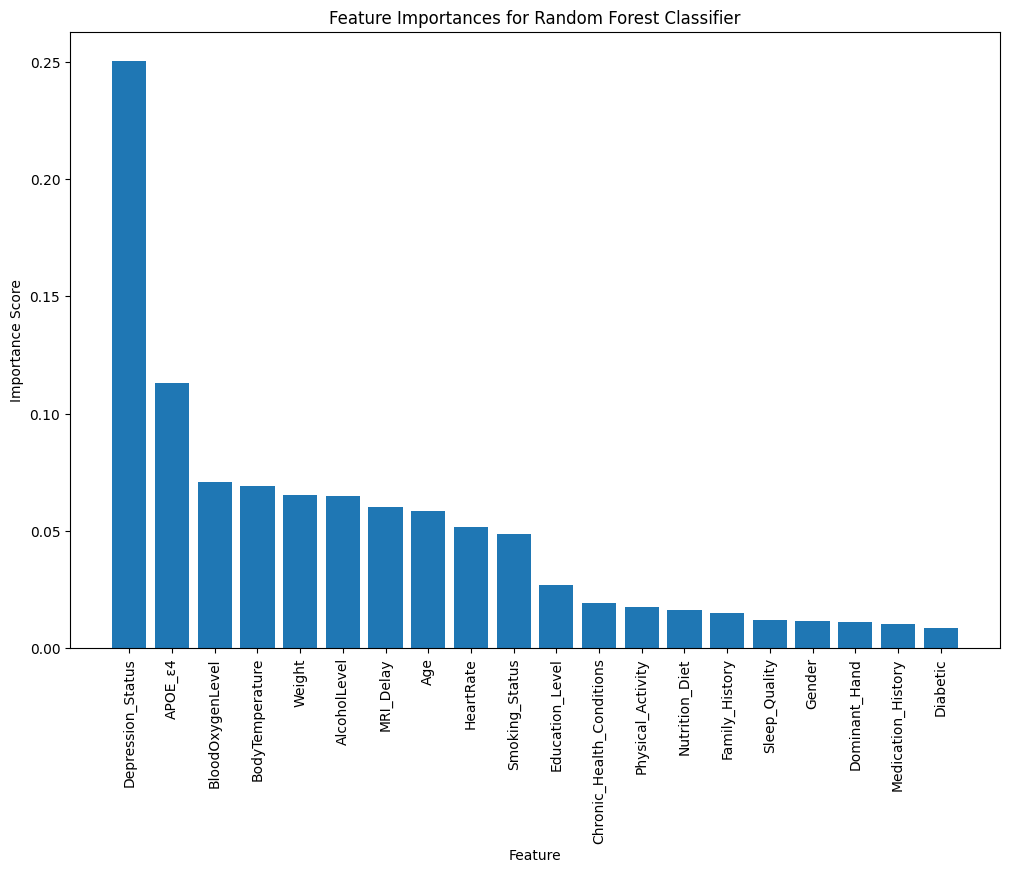

In [ ]:
#Feature of Importance Graph
importances = rfc.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 8))
plt.title("Feature Importances for Random Forest Classifier")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.show()

When I was doing this project I accidently did a decison tree instead of the random forest that I originally planned on doing. After doing the random forest I was glad that I made the mistake of accidently doing a decision tree because it allowed me to reasearch and learn the differances and similarities between the two types of models.  

###### While doing this I learned that random forests combines decison trees which reduces overfitting. This is the reason why the ROC curve for the decision tree and the random forest are different. The Roc curve for the decison tree has a sharp edge because the possibility of overfitting

---

## **LOGISTIC REGRESSION**

In [ ]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
#TESTING DATA PREDICITION
y_pred = lr.predict(X_test)

def accuracy(y_pred, y_test):
  return np.sum(y_pred == y_test)/len(y_test)

In [ ]:
# CLASSIFICATION REPORT
print(" "*4+'CLASSIFICATION REPORT for LOGISTIC REGRESSION\n' + '-'*60)
print(classification_report(y_test, y_pred))

    CLASSIFICATION REPORT for LOGISTIC REGRESSION
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.71      0.88      0.78       156
           1       0.82      0.60      0.70       144

    accuracy                           0.75       300
   macro avg       0.76      0.74      0.74       300
weighted avg       0.76      0.75      0.74       300



In [ ]:
# CONFUSION MATRIX
print(confusion_matrix(y_test, y_pred))

[[137  19]
 [ 57  87]]


In [ ]:
# ACCURACY
acc = accuracy(y_pred, y_test)
print(f'Logistic Regression Accuracy:', acc)

Logistic Regression Accuracy: 0.7466666666666667


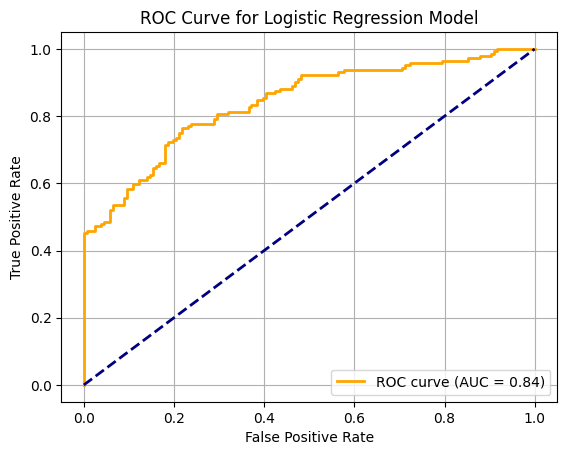

In [ ]:
# Predictions on the test data
y_pred_proba = lr.predict_proba(X_test)[:, 1]  #Predict probabilities for positives
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)  #False positive rate (FPR), true positive rate (TPR)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='orange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

---

## **SUPPORT VECTOR MACHINE**

In [ ]:
from sklearn import svm

#Create a svm Classifier
supportvm = svm.SVC(kernel='linear', C=1000.0, random_state = 0) # Linear Kernel

#Train the model
supportvm.fit(X_train, y_train)

#Prediction for testing
y_pred_svm = supportvm.predict(X_test)


In [ ]:
print(" "*4+'CLASSIFICATION REPORT for SUPPORT VECTOR MACHINE\n' + '-'*60)
print(classification_report(y_test, y_pred_svm))

    CLASSIFICATION REPORT for SUPPORT VECTOR MACHINE
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.70      0.81      0.75       156
           1       0.75      0.62      0.68       144

    accuracy                           0.72       300
   macro avg       0.73      0.72      0.72       300
weighted avg       0.72      0.72      0.72       300



In [ ]:
# Model Accuracy
print("Accuracy:",metrics.accuracy_score(y_test, y_pred_svm))

Accuracy: 0.72


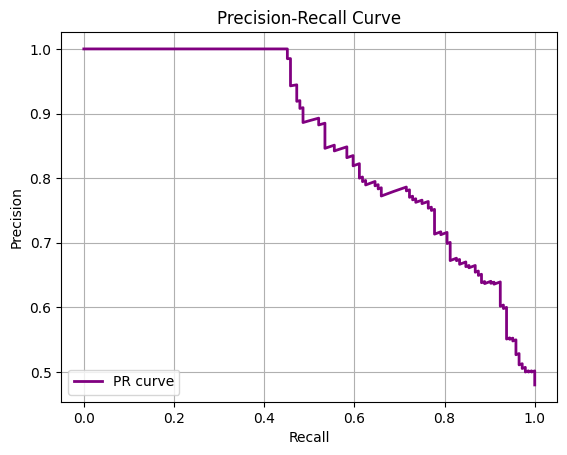

In [ ]:
from sklearn.metrics import precision_recall_curve

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plot PR curve
plt.figure()
plt.plot(recall, precision, color='purple', lw=2, label='PR curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()